In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_moons
from sklearn.metrics.pairwise import rbf_kernel

# Modern Qiskit imports
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Seed for reproducibility
seed = 12345

# Generate dataset
X, y = make_moons(n_samples=100, noise=0.2, random_state=seed)

# Scale features to [0, 1] for angle encoding
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=seed
)

# Define number of features and qubits
num_features = X_train.shape[1]
num_qubits = num_features 

print(f"Number of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of features/qubits: {num_qubits}")

Number of training samples: 70
Number of testing samples: 30
Number of features/qubits: 2


In [10]:
z_feature_map = ZFeatureMap(num_qubits, 1)
z_kernel = FidelityQuantumKernel(feature_map = z_feature_map)


print("Calculating Z Kernel Matrix (Train)...")
kernel_matrix_train_z = z_kernel.evaluate(x_vec=X_train)

# Kernel matrix for testing data (X_test vs X_train)
print("Calculating Z Kernel Matrix (Test)...")
kernel_matrix_test_z = z_kernel.evaluate(x_vec=X_test, y_vec=X_train)

print("Z Kernel Matrices calculated.")

/var/folders/m9/3nzfzfxj289195w21ntjp4m40000gn/T/ipykernel_2790/4015245791.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  z_feature_map = ZFeatureMap(num_qubits, 1)


Calculating Z Kernel Matrix (Train)...
Calculating Z Kernel Matrix (Test)...
Z Kernel Matrices calculated.


In [16]:
zz_feature_map = ZZFeatureMap(num_qubits, 1)
zz_kernel = FidelityQuantumKernel(feature_map = zz_feature_map)


print("Calculating Z Kernel Matrix (Train)...")
kernel_matrix_train_zz = zz_kernel.evaluate(x_vec=X_train)

# Kernel matrix for testing data (X_test vs X_train)
print("Calculating Z Kernel Matrix (Test)...")
kernel_matrix_test_zz = zz_kernel.evaluate(x_vec=X_test, y_vec=X_train)

print("Z Kernel Matrices calculated.")

/var/folders/m9/3nzfzfxj289195w21ntjp4m40000gn/T/ipykernel_2790/1213296722.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  zz_feature_map = ZZFeatureMap(num_qubits, 1)


Calculating Z Kernel Matrix (Train)...
Calculating Z Kernel Matrix (Test)...
Z Kernel Matrices calculated.


In [17]:

# Calculate RBF kernel matrices
gamma_val = 0.5 # Common heuristic
print("Calculating RBF Kernel Matrix (Train & Test)...")
kernel_matrix_train_rbf = rbf_kernel(X_train, X_train, gamma=gamma_val)
kernel_matrix_test_rbf = rbf_kernel(X_test, X_train, gamma=gamma_val)

print("RBF Kernel Matrices calculated.")


Calculating RBF Kernel Matrix (Train & Test)...
RBF Kernel Matrices calculated.


In [18]:
# Train SVM using the Z Feature Map Kernel
svm_z = SVC(kernel='precomputed', C=1.0, random_state=seed)
print("Training SVM with Z Kernel...")
svm_z.fit(kernel_matrix_train_z, y_train)
print("Training complete.")

# Train SVM using the ZZ Feature Map Kernel
svm_zz = SVC(kernel='precomputed', C=1.0, random_state=seed)
print("Training SVM with ZZ Kernel...")
svm_zz.fit(kernel_matrix_train_zz, y_train)
print("Training complete.")

# Train SVM using the RBF Kernel
svm_rbf = SVC(kernel='precomputed', C=1.0, random_state=seed)
print("Training SVM with RBF Kernel...")
svm_rbf.fit(kernel_matrix_train_rbf, y_train)
print("Training complete.")


Training SVM with Z Kernel...
Training complete.
Training SVM with ZZ Kernel...
Training complete.
Training SVM with RBF Kernel...
Training complete.


In [19]:
# Evaluate Z Kernel SVM
print("Evaluating Z Kernel SVM...")
score_z = svm_z.score(kernel_matrix_test_z, y_test)
print(f"Accuracy (Z Kernel): {score_z:.4f}")

# Evaluate ZZ Kernel SVM
print("Evaluating ZZ Kernel SVM...")
score_zz = svm_zz.score(kernel_matrix_test_zz, y_test)
print(f"Accuracy (ZZ Kernel): {score_zz:.4f}")

# Evaluate RBF Kernel SVM
print("Evaluating RBF Kernel SVM...")
score_rbf = svm_rbf.score(kernel_matrix_test_rbf, y_test)
print(f"Accuracy (RBF Kernel): {score_rbf:.4f}")


Evaluating Z Kernel SVM...
Accuracy (Z Kernel): 0.9000
Evaluating ZZ Kernel SVM...
Accuracy (ZZ Kernel): 0.9000
Evaluating RBF Kernel SVM...
Accuracy (RBF Kernel): 0.8667


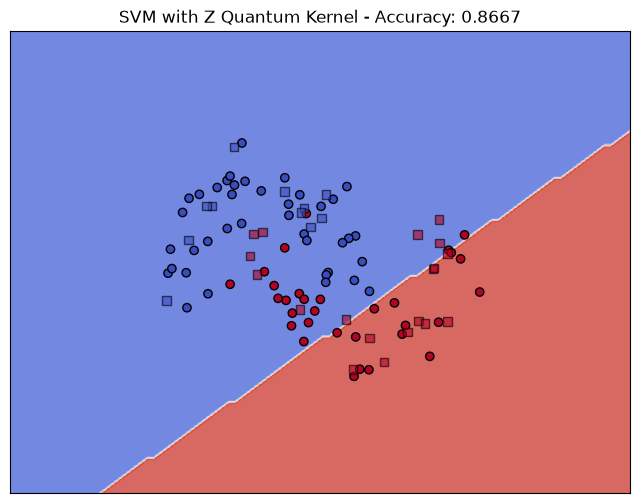

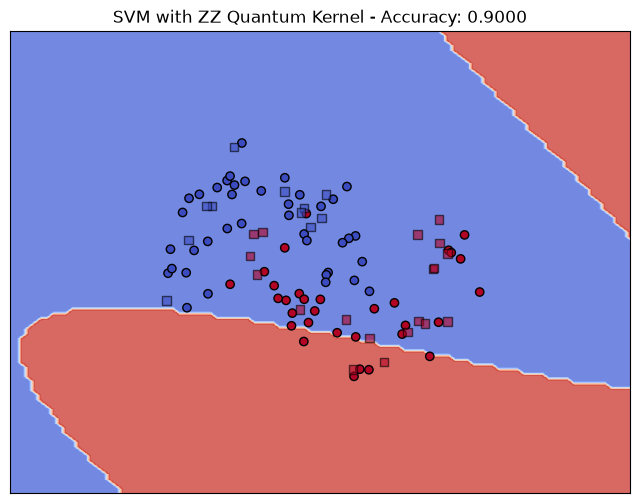

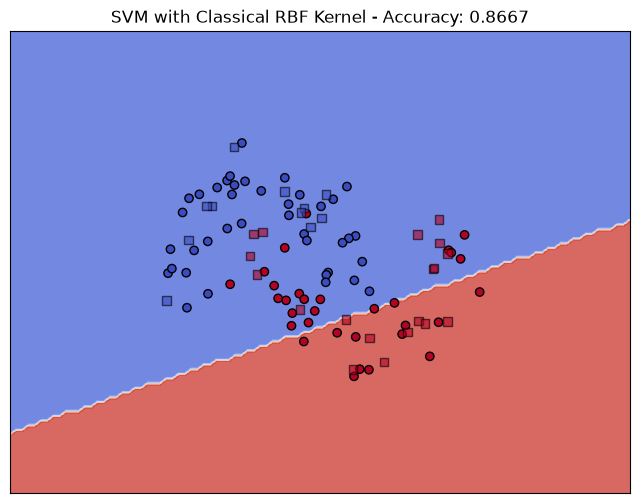

In [20]:
def plot_decision_boundary(X, y, svm_model, kernel_matrix_func, title):
    """
    Plots the decision boundary for a precomputed kernel SVM.
    kernel_matrix_func(grid_points, X_train) -> kernel matrix
    """
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on the mesh grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    # Important: Scale grid points like the training data
    grid_points_scaled = scaler.transform(grid_points) # Use the same scaler

    # Calculate kernel matrix between grid points and training data
    kernel_grid = kernel_matrix_func(grid_points_scaled, X_train)

    Z = svm_model.predict(kernel_grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot training points
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
    # Plot test points slightly differently
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', marker='s', alpha=0.6)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(f'{title} - Accuracy: {svm_model.score(kernel_matrix_func(X_test, X_train), y_test):.4f}')
    plt.show()

# Create kernel calculation functions for plotting
def kernel_z_eval(X1, X2):
    return z_kernel.evaluate(x_vec=X1, y_vec=X2)

def kernel_zz_eval(X1, X2):
    return zz_kernel.evaluate(x_vec=X1, y_vec=X2)

def kernel_rbf_eval(X1, X2):
    return rbf_kernel(X1, X2, gamma=gamma_val)


# Plot decision boundaries (using original unscaled data for plotting limits)
plot_decision_boundary(X_scaled, y, svm_z, kernel_z_eval, "SVM with Z Quantum Kernel")
plot_decision_boundary(X_scaled, y, svm_zz, kernel_zz_eval, "SVM with ZZ Quantum Kernel")
plot_decision_boundary(X_scaled, y, svm_rbf, kernel_rbf_eval, "SVM with Classical RBF Kernel")

